In [20]:
import rasterio
import matplotlib.pyplot as plt
from s3fs import S3FileSystem
from IPython.display import display, Markdown
import json

# Configuração da sua plataforma LambdaGeo
s3 = S3FileSystem(
    key='inpe_admin',
    secret='inpe_secret_2024',
    client_kwargs={'endpoint_url': 'http://minio:9000'}
)

Lendo profiling em: s3://dissmodel-outputs/experiments/81aff60ba0c64e81b8b7fb1917946146/profiling_81aff60b.md


# Profiling Report: coastal_raster

**Experiment ID:** `81aff60ba0c64e81b8b7fb1917946146`
**Date:** `2026-04-08T14:36:39.825548`
**Execution Node:** `Cloud Worker`

## Execution Times

| Phase | Time (seconds) | % of Total |
|---|---|---|
| **Validate** | 0.000 | 0.0% |
| **Run** | 5.478 | 93.2% |
| **Save** | 0.397 | 6.8% |
| **Total** | **5.875** | **100%** |


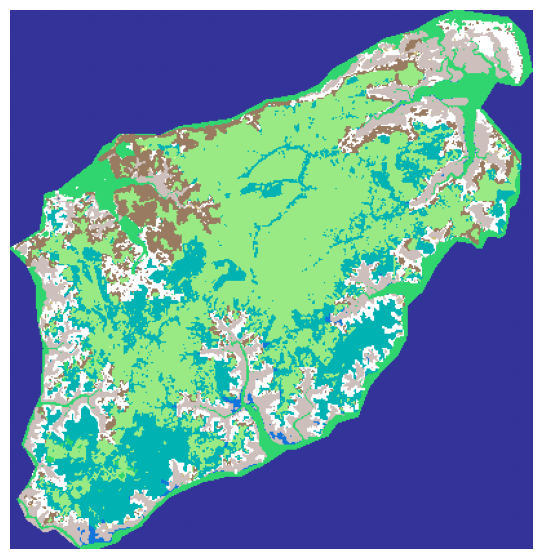

In [21]:
# O caminho do JSON que o worker salvou (ID de 8 caracteres)
experiment_id_short = "81aff60b"
base_uri = f"s3://dissmodel-outputs/experiments/81aff60ba0c64e81b8b7fb1917946146"
record_uri = f"{base_uri}/{experiment_id_short}.record.json"

# ── 1. Ler os Metadados (O GPS do experimento) ──
with s3.open(record_uri, 'r') as f:
    record_data = json.load(f)

# O ID curto que usamos nos nomes dos arquivos
short_id = record_data['experiment_id'][:8]

# ── 2. Mostrar o Profiling (Reconstruindo o caminho) ──
# Em vez de pegar de record_data['artifacts']['profiling'] (que é o hash),
# nós usamos o padrão: base_dir/profiling_ID.md
profiling_uri = f"{base_uri}/profiling_{short_id}.md"

print(f"Lendo profiling em: {profiling_uri}")

with s3.open(profiling_uri, 'r') as f:
    display(Markdown(f.read()))

# ── 3. Visualizar o Mapa ──
# O output_path geralmente já está completo no JSON
tif_uri = record_data['output_path']

with s3.open(tif_uri, 'rb') as f:
    with rasterio.open(f) as src:
        data = src.read(1)
        plt.figure(figsize=(10, 7))
        plt.imshow(data, cmap='terrain')
        plt.axis('off')
        plt.show()